**Materi ini dibuat oleh : [Sardi Irfansyah](https://www.linkedin.com/in/sardi-irfansyah-947bb554/)**


# Alur Pengerjaan Machine Learning

Pada Bagian ini kita akan melakukan latihan menggunakan Dataset Telco Customer Churn. Kita akan menggunakan model Decision Tree, Random Forest, AdaBoost dan Stacking untuk memprediksi Churn.

Berikut adalah alur pembuatan projectnya:
- Definisikan terlebih dahulu tujuan dan permasalahan bisnis yang dihadapi
- Setelah mengetahui hal tersebut pastikan kembali sudah ada datanya atau belum? kalau sudah ada maka bisa lanjutkan ke proses selanjutnya
- Pahami data yang digunakan, misalkan pahami atribut apa saja yang ada dalam data tersebut.
- Explore Datanya untuk memahami data tersebut:
  - Cek Distribusi data
  - Melakukan analisis statisika
  - Cek Apakah ada data yang hilang
  - Cek apakah ada outlier
  - Cek apakah ada korelasi atau hubungan antara fitur dan target
- Preprocessing & FE (feature Engineering):
  - Imputasi data yang hilang
  - Tangani outlier
  - Scaling
  - Encoding
  - reduksi dimensi
  - Transformasi data
  - dll
- Model Development:
  - Tentukan model yang tepat berdasarkan data yang sudah kita explore (EDA), misalkan kita mengetahui pola datanya non linear, maka mungkin kita bisa menggunakan pemodelan non-linear seperti Decision Tree atau Random Forest
  - Melakukan uji coba beberpaa model dasar, misalkan membandingkan Logisitic Regression dengan Decision Tree
  - Evaluasi Model, model mana yang terbaik
  - Hyperparameter tuning: Meningkatkan kinerja model dengan mencari parameter yang tepat untuk model tersebut
  - Model yang terbaik akan di simpan
- Model inference: Menguji coba model yang telah disimpan ke data yang baru
- Deployment


# Telco Customer Churn

## Background

Pada bagian ini jelaskan latar belakang dari project yang dibuat.

## Objective

Pada bagian ini jelaskan Objective dari project yang dibuat.

## Key Questions

Pada bagian ini buatlah beberapa pertanyaan yang nantinya akan kita explore untuk mendapatkan jawabannya. Contohnya seperti berikut ini.

Berdasarkan dataset Churn Prediction, kita akan fokus untuk menjawab pertanyaan berikut:
- Bagaimana distribusi Jumlah Churn di antara pelanggan berdasarkan jenis kelamin?
- Apakah pelanggan yang tergolong senior citizen cenderung memiliki churn rate yang lebih tinggi dibandingkan dengan non-senior?
- Apakah tenure (durasi berlangganan) berpengaruh terhadap churn rate?

## Import Libraries

In [ ]:
!pip install scikit-learn feature-engine==1.8.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.0/375.0 kB 5.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler, OneHotEncoder, OrdinalEncoder,PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_validate

# Model yang akan digunakan
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier

In [ ]:
import sklearn
print('scikit learn version:', sklearn.__version__)

scikit learn version: 1.5.2


## Data Loading & Data Validation

In [ ]:
#!/bin/bash
!kaggle datasets download blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
  0% 0.00/172k [00:00<?, ?B/s]
100% 172k/172k [00:00<00:00, 16.1MB/s]


In [ ]:
!unzip -q /content/telco-customer-churn.zip

In [ ]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Berikut ini adalah keterangan dari setiap atribut dalam Dataset tersebut:

| No  | Atribut           | Tipe Data | Deskripsi                                                                                          |
|-----|--------------------|-----------|---------------------------------------------------------------------------------------------------|
| 1   | customerID        | object    | ID unik untuk setiap pelanggan.                                                                   |
| 2   | gender            | object    | Jenis kelamin pelanggan.                                                                          |
| 3   | SeniorCitizen     | int64     | Menunjukkan apakah pelanggan adalah lansia (0 untuk bukan lansia, 1 untuk lansia).               |
| 4   | Partner           | object    | Menunjukkan apakah pelanggan memiliki pasangan atau tidak.                                        |
| 5   | Dependents        | object    | Menunjukkan apakah pelanggan memiliki tanggungan atau tidak.                                      |
| 6   | tenure            | int64     | Lama waktu (dalam bulan) pelanggan menggunakan layanan.                                           |
| 7   | PhoneService      | object    | Menunjukkan apakah pelanggan memiliki layanan telepon.                                            |
| 8   | MultipleLines     | object    | Menunjukkan apakah pelanggan memiliki lebih dari satu jalur telepon.                              |
| 9   | InternetService   | object    | Jenis layanan internet yang digunakan pelanggan (misalnya DSL, Fiber optic, atau tidak ada).      |
| 10  | OnlineSecurity    | object    | Menunjukkan apakah pelanggan memiliki layanan keamanan online.                                    |
| 11  | OnlineBackup      | object    | Menunjukkan apakah pelanggan memiliki layanan backup online.                                      |
| 12  | DeviceProtection  | object    | Menunjukkan apakah pelanggan memiliki layanan perlindungan perangkat.                             |
| 13  | TechSupport       | object    | Menunjukkan apakah pelanggan memiliki layanan dukungan teknis.                                    |
| 14  | StreamingTV       | object    | Menunjukkan apakah pelanggan memiliki layanan streaming TV.                                       |
| 15  | StreamingMovies   | object    | Menunjukkan apakah pelanggan memiliki layanan streaming film.                                     |
| 16  | Contract          | object    | Jenis kontrak yang dipilih pelanggan (misalnya bulanan, tahunan).                                 |
| 17  | PaperlessBilling  | object    | Menunjukkan apakah pelanggan menggunakan tagihan tanpa kertas (paperless).                        |
| 18  | PaymentMethod     | object    | Metode pembayaran yang digunakan pelanggan (misalnya kartu kredit, transfer otomatis).            |
| 19  | MonthlyCharges    | float64   | Jumlah tagihan bulanan yang dibayarkan oleh pelanggan.                                            |
| 20  | TotalCharges      | object    | Total jumlah tagihan selama pelanggan menggunakan layanan. Perlu diubah menjadi tipe `float64`.   |
| 21  | Churn             | object    | Menunjukkan apakah pelanggan berhenti berlangganan (churn) atau tetap (target analisis churn).   |


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


tampak tidak ada missing values, tapi kalau diperhatikan baik-baik ada tipe data yang tidak sesuai, yaitu kolom `TotalCharges`

In [ ]:
df['TotalCharges'].head() #seharusnya tipe datanya float tapi ternyata object

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [ ]:
# deteksi data yang non numerik
numeric_total_charges= pd.to_numeric(df['TotalCharges'], errors='coerce')
non_numeric_rows = df[numeric_total_charges.isna()]
display(non_numeric_rows)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
#konversi nilai pada kolom TotalCharges menjadi numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Identifikasi baris yang non-numerik
non_numeric_rows = df[df['TotalCharges'].isna()]

#Menampilkan baris yang non-numerik
display(non_numeric_rows['TotalCharges'])

,TotalCharges
488,NaN
753,NaN
936,NaN
1082,NaN
1340,NaN
3331,NaN
3826,NaN
4380,NaN
5218,NaN
6670,NaN


In [ ]:
df['TotalCharges'].dtype

dtype('float64')

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Ternyata ada missing values di `TotalCharges` nanti kita akan selediki terlebih dahulu terhadap data tersebut sebelum kita melakukan imputais.

In [ ]:
#cek duplikasi data
print('data terduplikasi',df.duplicated().sum())

#drop duplikasi data
# df.drop_duplicates(inplace=True)

data terduplikasi 0


## EDA (Exploratory Data Analysis)

In [ ]:
categorical_cols= list(df.select_dtypes(include='object').columns)
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [ ]:
numerical_cols= list(df.select_dtypes(include='number').columns)
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
df['SeniorCitizen'].unique() #harusnya ini data kategorikal, tapi sudah dalam bentuk numerik

array([0, 1])

In [ ]:
categorical_numeric_cols =['SeniorCitizen']
numerical_cols.remove('SeniorCitizen')

In [ ]:
numerical_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
churn_counts = df['Churn'].value_counts()
labels= churn_counts.index
values= churn_counts.values

labels

Index(['No', 'Yes'], dtype='object', name='Churn')

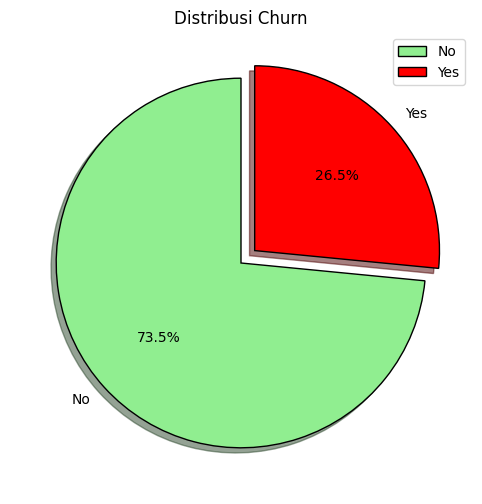

In [ ]:
# pie chart

colors= ['lightgreen','red']
explode= (0,0.1)

plt.figure(figsize=(10,6))
plt.pie(churn_counts,
        colors=colors,
        explode=explode,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        shadow=True,
        wedgeprops={'edgecolor':'black'})

plt.title('Distribusi Churn')
plt.legend()
plt.show()

In [ ]:
df['gender'].value_counts(normalize=True)

,proportion
gender,
Male,0.504756
Female,0.495244


In [ ]:
df.groupby('gender')['Churn'].value_counts(normalize=True)

gender  Churn
Female  No       0.730791
        Yes      0.269209
Male    No       0.738397
        Yes      0.261603
Name: proportion, dtype: float64

Insight:
- Persentase antara orang yang Churn berdasarkan jenis kelaminnya adalah cenderung mirip.
- Gender tidak mempengaruhi seseorang Churn.

In [ ]:
#melihat persentase churn untuk Customer yang tergolong SeniorCitizen
df[df['SeniorCitizen']==1]['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.583187
Yes,0.416813


In [ ]:
df[df['SeniorCitizen']==0]['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.763938
Yes,0.236062


In [ ]:
sc_churn_rate= pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')
sc_churn_rate

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


Insight:
- Persentase customer yang Churn cenderung lebih tinggi ketika statusnya adalah SeniorCitizen.
- Ada kemungkinan SeniorCitizen merupakan fitur yang mempengaruhi seseorang Churn.

In [ ]:
median_monthly_charges= df['MonthlyCharges'].median()
median_monthly_charges

70.35

In [ ]:
# groupby seniorcitizen untuk median monthly charges
df.groupby('SeniorCitizen')['MonthlyCharges'].median()

,MonthlyCharges
SeniorCitizen,
0,65.80
1,84.85


In [ ]:
# groupby seniorcitizen untuk median monthly charges
df.groupby(['SeniorCitizen','Churn'])['MonthlyCharges'].median()

SeniorCitizen  Churn
0              No       59.750
               Yes      78.100
1              No       84.850
               Yes      84.825
Name: MonthlyCharges, dtype: float64

Insight:
- Orang yang lansia cederung memiliki tagihan bulanan yang lebih tinggi dibandingkan yang bukan lansia
- Orang lansia cenderung tagihan bulanannya lebih besar dari median.

Kesimpulannya ada kemungkinan SeniorCitizen yang Churn itu karena dia memiliki tagihan yang lebih cenderung tinggi.

In [ ]:
# groupby seniorcitizen untuk median monthly charges
df.groupby(['SeniorCitizen','Churn'])['tenure'].median()

SeniorCitizen  Churn
0              No       37.0
               Yes       9.0
1              No       45.0
               Yes      15.0
Name: tenure, dtype: float64

In [ ]:
# Fungsi untuk mengelompokkan tenure
def categorize_tenure(tenure):
    if tenure < 2:
        return 'Pelanggan Baru'
    elif tenure < 4:
        return 'Pelanggan Menengah'
    else:
        return 'Pelanggan Lama'

df['group_tenure']= df['tenure'].apply(categorize_tenure)

In [ ]:
df.groupby(['SeniorCitizen','Churn'])['group_tenure'].value_counts(normalize=True)

SeniorCitizen  Churn  group_tenure      
0              No     Pelanggan Lama        0.903505
                      Pelanggan Baru        0.051464
                      Pelanggan Menengah    0.045031
               Yes    Pelanggan Lama        0.660445
                      Pelanggan Baru        0.219670
                      Pelanggan Menengah    0.119885
1              No     Pelanggan Lama        0.954955
                      Pelanggan Menengah    0.027027
                      Pelanggan Baru        0.018018
               Yes    Pelanggan Lama        0.739496
                      Pelanggan Baru        0.155462
                      Pelanggan Menengah    0.105042
Name: proportion, dtype: float64

In [ ]:
# groupby jumlah churn berdasrakan group tenure
df.groupby(['Churn'])['group_tenure'].value_counts(normalize=True).unstack()

group_tenure,Pelanggan Baru,Pelanggan Lama,Pelanggan Menengah
Churn,,,
No,0.047159,0.910128,0.042714
Yes,0.203317,0.680578,0.116105


In [ ]:
ps_churn_rate= pd.crosstab(df['PhoneService'], df['Churn'], normalize='index')
ps_churn_rate

Churn,No,Yes
PhoneService,,
No,0.750733,0.249267
Yes,0.732904,0.267096


In [ ]:
ml_churn_rate= pd.crosstab(df['MultipleLines'], df['Churn'], normalize='index')
ml_churn_rate

Churn,No,Yes
MultipleLines,,
No,0.749558,0.250442
No phone service,0.750733,0.249267
Yes,0.713901,0.286099


In [ ]:
is_churn_rate= pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
is_churn_rate

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


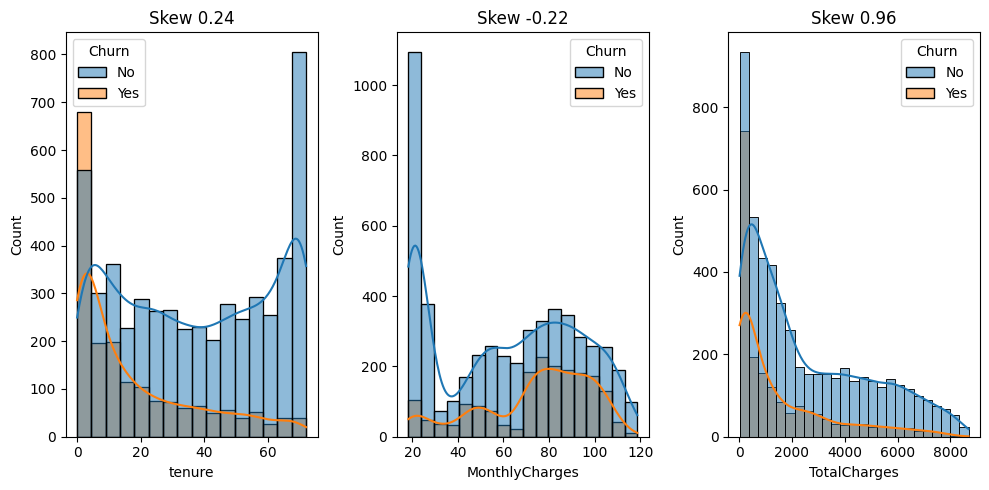

In [ ]:
fig,ax= plt.subplots(1,3,figsize=(10,5))

#numerical cols
for i,col in enumerate(numerical_cols):
  sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax[i])
  ax[i].set_title(f'Skew {df[col].skew():.2f}')
  plt.tight_layout();

In [ ]:
def find_skewed_boundaries(df, variable, distance):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * distance)
    upper_boundary = df[variable].quantile(0.75) + (IQR * distance)

    return upper_boundary, lower_boundary

In [ ]:
upper_boundary, lower_boundary= find_skewed_boundaries(df, 'TotalCharges', 1.5)
print('upper boundary:',upper_boundary)
print('lower boundary:',lower_boundary)

upper boundary: 8884.66875
lower boundary: -4688.481250000001


In [ ]:
df.query('TotalCharges > @upper_boundary')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,group_tenure


In [ ]:
# cek outlier untuk total charges
df[(df['TotalCharges']>upper_boundary) | (df['TotalCharges']<lower_boundary)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,group_tenure


In [ ]:
def outlier_summary_table(df, col_name):
    # Inisialisasi list kosong untuk menyimpan hasil
    summary_data = []

    # Loop melalui setiap kolom numerik di dalam dataframe
    for column in col_name:
        # Menghitung Q1 (Kuartil pertama) dan Q3 (Kuartil ketiga)
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        # Menghitung IQR (Interquartile Range)
        IQR = Q3 - Q1

        # Menentukan batas bawah dan batas atas untuk mendeteksi outlier
        lower_boundary = Q1 - 1.5 * IQR
        upper_boundary = Q3 + 1.5 * IQR

        # Menghitung persentase outlier
        outliers = df[(df[column] < lower_boundary) | (df[column] > upper_boundary)]
        outlier_percentage = (len(outliers) / len(df)) * 100

        # Menyimpan hasil dalam list
        summary_data.append({
            'atribut': column,
            'lower_boundary': lower_boundary,
            'upper_boundary': upper_boundary,
            'persentase outlier': outlier_percentage
        })

    # Mengonversi hasil ke dalam DataFrame
    summary_table = pd.DataFrame(summary_data)
    return summary_table

In [ ]:
outlier_summary_table(df, numerical_cols)

,atribut,lower_boundary,upper_boundary,persentase outlier
0,tenure,-60.00000,124.00000,0.0
1,MonthlyCharges,-46.02500,171.37500,0.0
2,TotalCharges,-4688.48125,8884.66875,0.0


In [ ]:
df.groupby('Churn')[numerical_cols].median()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.425,1683.60
Yes,10.0,79.650,703.55


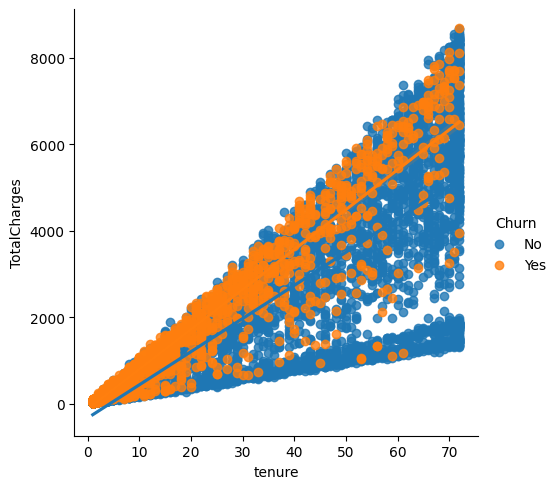

In [ ]:
sns.lmplot(data=df, x='tenure',y='TotalCharges', hue='Churn');

Referensi teknik untuk seleksi fitur atau pengecekan hubungan fitur dan target:
- https://machinelearningmastery.com/wp-content/uploads/2019/11/How-to-Choose-Feature-Selection-Methods-For-Machine-Learning.png

In [ ]:
correlation= df['Churn'].map({'No':0,'Yes':1}).corr(df['tenure'],method='kendall')
print('koefisien kolerasi antara Churn dan tenure:',correlation)

koefisien kolerasi antara Churn dan tenure: -0.3029650182111258


In [ ]:
cat_cols= df.select_dtypes(include='object').columns
cat_cols = cat_cols[cat_cols != 'customerID'] #hilangkan customerID
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn', 'group_tenure'],
      dtype='object')

In [ ]:
from scipy.stats import chi2_contingency


# Inisialisasi list untuk menyimpan hasil
chi2_results_list = []

# Iterasi melalui semua kolom kategorikal
for col in cat_cols:
    # Buat tabel kontingensi
    contingency_table = pd.crosstab(df[col], df['Churn'])

    # Lakukan uji Chi-Square
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    alpha=0.05
    # Tambahkan hasil ke list
    chi2_results_list.append({'Nama Atribut': col,
                              'Chi2 Stat': round(chi2_stat,3),
                              'P-value': round(p_val,3),
                              #result berko
                              'result': 'correlated' if p_val <= alpha else 'not correlated'
                              })


# Buat DataFrame dari list
chi2_results = pd.DataFrame(chi2_results_list)

# Tampilkan DataFrame hasil
display(chi2_results)

,Nama Atribut,Chi2 Stat,P-value,result
0,gender,0.484,0.487,not correlated
1,Partner,158.733,0.000,correlated
2,Dependents,189.129,0.000,correlated
3,PhoneService,0.915,0.339,not correlated
4,MultipleLines,11.330,0.003,correlated
5,InternetService,732.310,0.000,correlated
6,OnlineSecurity,849.999,0.000,correlated
7,OnlineBackup,601.813,0.000,correlated
8,DeviceProtection,558.419,0.000,correlated
9,TechSupport,828.197,0.000,correlated


## Data Preprocessing

Disini kita akan bereksperimen dengan menggunakan semua fitur selain CustomerID dan group_tenure.

**Catatan**: Kalian boleh juga langsung mengambil beberapa fitur yang menurut berkolerasi setelah melakukan EDA.

In [ ]:
X= df.drop(columns=['Churn','customerID','group_tenure'],axis=1)
y= df['Churn']

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,
                                                   random_state=42, stratify=y)


In [ ]:
X_train.shape

(5634, 19)

In [ ]:
y_train.head()

,Churn
3738,No
3151,No
4860,No
3867,No
3810,No


In [ ]:
# label encoder
y_train= y_train.map({'No':0,'Yes':1})
y_test= y_test.map({'No':0,'Yes':1})

In [ ]:
categorical_cols= list(X_train.select_dtypes(include='object').columns)
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [ ]:
numerical_cols= list(X_train.select_dtypes(include='number').columns)
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

'SeniorCitizen' adalah fitur kategorikal dalam bentuk numerik, jadi harus kita hapus dari list fitur numerik.

In [ ]:
enc_categorical_features= ['SeniorCitizen']
numerical_cols.remove('SeniorCitizen')

In [ ]:
numerical_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
# pipeline

categorical_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first',handle_unknown='ignore')),
])

numerical_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), # MinMaxScaler(feature_range=(1, 2) jika gunakan box-cox harus tidak boleh ada minus atau 0
    #('power_transformer', PowerTransformer(method='yeo-johnson')),  # Menggunakan metode yeo-johson
])

enc_categorical_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

preprocessor= ColumnTransformer(
    transformers=[
      ('numerical', numerical_pipeline, numerical_cols),
      ('categorical_ohe', categorical_pipeline, categorical_cols),
      ('categorical_enc', enc_categorical_pipeline, enc_categorical_features),
],
remainder='passthrough',
verbose=True
)

In [ ]:
X_train_preprocessed= preprocessor.fit_transform(X_train)
X_test_preprocessed= preprocessor.transform(X_test)

[ColumnTransformer] ..... (1 of 3) Processing numerical, total=   0.0s
[ColumnTransformer]  (2 of 3) Processing categorical_ohe, total=   0.1s
[ColumnTransformer]  (3 of 3) Processing categorical_enc, total=   0.0s


In [ ]:
preprocessor.get_feature_names_out()

array(['numerical__tenure', 'numerical__MonthlyCharges',
       'numerical__TotalCharges', 'categorical_ohe__gender_Male',
       'categorical_ohe__Partner_Yes', 'categorical_ohe__Dependents_Yes',
       'categorical_ohe__PhoneService_Yes',
       'categorical_ohe__MultipleLines_No phone service',
       'categorical_ohe__MultipleLines_Yes',
       'categorical_ohe__InternetService_Fiber optic',
       'categorical_ohe__InternetService_No',
       'categorical_ohe__OnlineSecurity_No internet service',
       'categorical_ohe__OnlineSecurity_Yes',
       'categorical_ohe__OnlineBackup_No internet service',
       'categorical_ohe__OnlineBackup_Yes',
       'categorical_ohe__DeviceProtection_No internet service',
       'categorical_ohe__DeviceProtection_Yes',
       'categorical_ohe__TechSupport_No internet service',
       'categorical_ohe__TechSupport_Yes',
       'categorical_ohe__StreamingTV_No internet service',
       'categorical_ohe__StreamingTV_Yes',
       'categorical_ohe__St

In [ ]:
#buat dataframe X_train_preprocessed
X_train_preprocessed= pd.DataFrame(X_train_preprocessed, columns=preprocessor.get_feature_names_out())
X_test_preprocessed= pd.DataFrame(X_test_preprocessed, columns=preprocessor.get_feature_names_out())

In [ ]:
X_train_preprocessed.shape

(5634, 30)

Jumlah dimensi setelah dilakukan encoding dengan OneHotEncoder adalah 30

In [ ]:
y_train.head(2)

,Churn
0,0
1,0


In [ ]:
#lakukan reset index agar indexnya sama dengan fitur
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

data_train= pd.concat([X_train_preprocessed, y_train], axis=1)
data_test= pd.concat([X_test_preprocessed, y_test], axis=1)

In [ ]:
corr_train=data_train.corr(method='spearman')['Churn'].abs().sort_values(ascending=False)
corr_train.loc['categorical_ohe__InternetService_Fiber optic':'categorical_enc__SeniorCitizen'].index

Index(['categorical_ohe__InternetService_Fiber optic',
       'categorical_ohe__PaymentMethod_Electronic check',
       'categorical_ohe__Contract_Two year',
       'categorical_ohe__DeviceProtection_No internet service',
       'categorical_ohe__OnlineBackup_No internet service',
       'categorical_ohe__StreamingMovies_No internet service',
       'categorical_ohe__StreamingTV_No internet service',
       'categorical_ohe__TechSupport_No internet service',
       'categorical_ohe__InternetService_No',
       'categorical_ohe__OnlineSecurity_No internet service',
       'numerical__TotalCharges', 'categorical_ohe__PaperlessBilling_Yes',
       'numerical__MonthlyCharges', 'categorical_ohe__Contract_One year',
       'categorical_ohe__OnlineSecurity_Yes',
       'categorical_ohe__Dependents_Yes', 'categorical_ohe__TechSupport_Yes',
       'categorical_ohe__Partner_Yes', 'categorical_enc__SeniorCitizen'],
      dtype='object')

In [ ]:
X_train_selected= X_train_preprocessed.loc[:,corr_train.loc['categorical_ohe__InternetService_Fiber optic':'categorical_enc__SeniorCitizen'].index]
X_test_selected= X_test_preprocessed.loc[:,corr_train.loc['categorical_ohe__InternetService_Fiber optic':'categorical_enc__SeniorCitizen'].index]

In [ ]:
print('jumlah fitur sebelum diselksi',X_train_preprocessed.shape[1])
print('jumlah fitur setelah di seleksi',X_train_selected.shape[1])

jumlah fitur sebelum diselksi 30
jumlah fitur setelah di seleksi 19


Sekarang jumlah fitur atau dimensi data kita adalah 19

# Model Development

## Decision Tree

In [ ]:
# pada decision tree atur class_weight='balanced' untuk menangani imbalance data
model_dt= DecisionTreeClassifier(random_state=42,
                                 class_weight='balanced')
model_dt.fit(X_train_selected, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
print(f"jumlah node dalam decision tree: {model_dt.tree_.node_count}")
print(f"kedalaman maksimum dalam decision tree: {model_dt.tree_.max_depth}")

jumlah node dalam decision tree: 2625
kedalaman maksimum dalam decision tree: 25


In [ ]:
from sklearn.tree import plot_tree

# plt.figure(figsize=(20,10))
# plot_tree(model_dt, filled=True, feature_names=X_train_selected.columns, class_names=['No', 'Yes'])
# plt.show()

In [ ]:
y_pred_train= model_dt.predict(X_train_selected)
y_pred_test= model_dt.predict(X_test_selected)

In [ ]:
print('Classification Report Train:')
print(classification_report(y_train, y_pred_train))

Classification Report Train:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4139
           1       0.99      1.00      0.99      1495

    accuracy                           1.00      5634
   macro avg       0.99      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634



In [ ]:
print('Classification Report Test:')
print(classification_report(y_test, y_pred_test))

Classification Report Test:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1035
           1       0.49      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



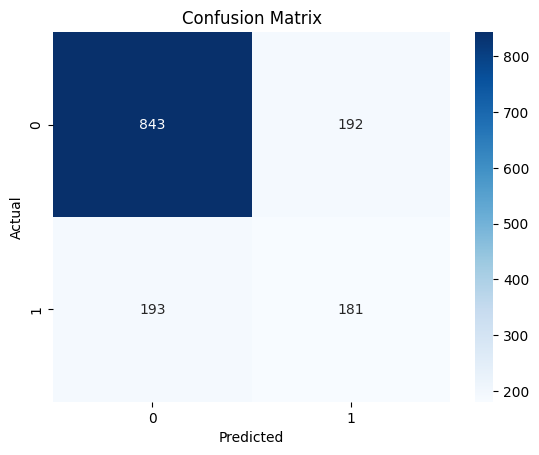

In [ ]:
# confusion matrix
cm= confusion_matrix(y_test, y_pred_test)

# plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
scoring = ['accuracy', 'precision', 'recall']
scores = cross_validate(model_dt, X_train_selected, y_train, scoring=scoring, cv=5)

print("Accuracy scores:", scores['test_accuracy'])
print("Precision scores:", scores['test_precision'])
print("Recall scores:", scores['test_recall'])

print("Mean Accuracy:", scores['test_accuracy'].mean())
print("Mean Precision:", scores['test_precision'].mean())
print("Mean Recall:", scores['test_recall'].mean())

Accuracy scores: [0.74090506 0.7364685  0.74001775 0.73735581 0.71403197]
Precision scores: [0.51111111 0.50326797 0.51111111 0.50485437 0.4637224 ]
Recall scores: [0.53846154 0.51505017 0.46153846 0.52173913 0.4916388 ]
Mean Accuracy: 0.7337558175637233
Mean Precision: 0.49881339249736206
Mean Recall: 0.505685618729097


## Random Forest

In [ ]:
rf_model= RandomForestClassifier(random_state=42,
                                 class_weight='balanced')
rf_model.fit(X_train_selected, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_train= rf_model.predict(X_train_selected)
y_pred_test= rf_model.predict(X_test_selected)

In [ ]:
print('Classification Report Train:')
print(classification_report(y_train, y_pred_train))

Classification Report Train:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4139
           1       0.99      1.00      0.99      1495

    accuracy                           1.00      5634
   macro avg       1.00      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634



In [ ]:
print('Classification Report Test:')
print(classification_report(y_test, y_pred_test))

Classification Report Test:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



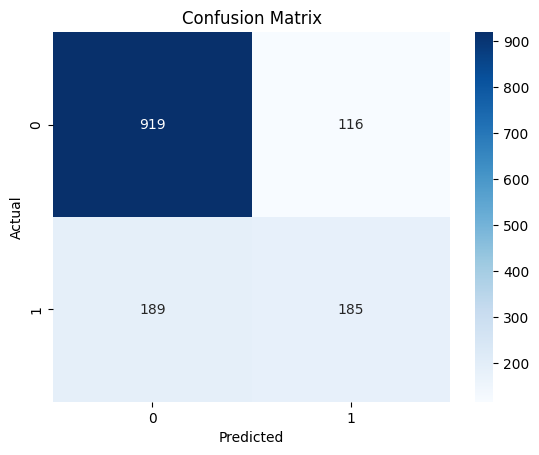

In [ ]:
# confusion matrix
cm= confusion_matrix(y_test, y_pred_test)

# plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision', 'recall']
scores = cross_validate(rf_model, X_train_selected, y_train, scoring=scoring, cv=5)

print("Accuracy scores:", scores['test_accuracy'])
print("Precision scores:", scores['test_precision'])
print("Recall scores:", scores['test_recall'])

print("Mean Accuracy:", scores['test_accuracy'].mean())
print("Mean Precision:", scores['test_precision'].mean())
print("Mean Recall:", scores['test_recall'].mean())

Accuracy scores: [0.78793256 0.78704525 0.80212955 0.77284827 0.76642984]
Precision scores: [0.62931034 0.62660944 0.66814159 0.58847737 0.57317073]
Recall scores: [0.48829431 0.48829431 0.50501672 0.47826087 0.47157191]
Mean Accuracy: 0.783277094913956
Mean Precision: 0.6171418955540975
Mean Recall: 0.4862876254180602


## Bosting

Dalam Scikit-Learn, penaksir dasar untuk boosting adalah Decision Tree. Namun, kita dapat mengubahnya menjadi algoritma lain.

In [ ]:
ada_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42,
                                                                     class_weight='balanced'),
                               n_estimators=50, # Number of weak learners (decision trees)
                               random_state=42,
                               algorithm='SAMME')

ada_model.fit(X_train_selected, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    random_state=42),
                   random_state=42)

Keterangan:
- **estimator**: Merupakan model dasar (base learner) yang digunakan oleh AdaBoost.
- **algorithm**: Menentukan algoritma boosting yang digunakan, ada 2 pilihan yaitu SAMME dan SAMME.R. SAMME adalah algoritma boosting diskrit, sedangkan SAMME.R merupakan versi yang dimodifikasi dan biasanya lebih cepat.

In [ ]:
y_pred_train = ada_model.predict(X_train_selected)
y_pred_test = ada_model.predict(X_test_selected)

print('Classification Report Train:')
print(classification_report(y_train, y_pred_train))
print('Classification Report Test:')
print(classification_report(y_test, y_pred_test))

Classification Report Train:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4139
           1       0.99      1.00      0.99      1495

    accuracy                           1.00      5634
   macro avg       0.99      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634

Classification Report Test:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1035
           1       0.48      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.73      1409



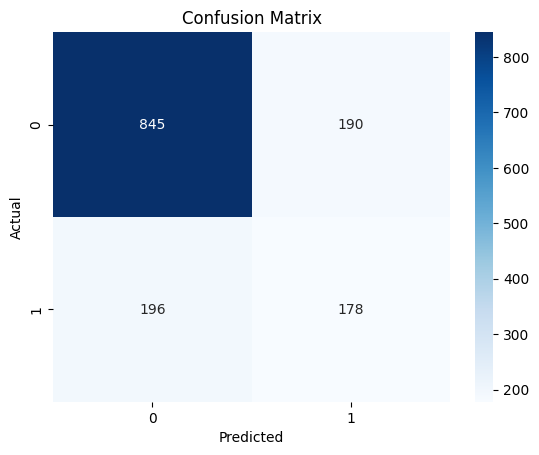

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
scoring = ['accuracy', 'precision', 'recall']
scores = cross_validate(ada_model, X_train_selected, y_train, scoring=scoring, cv=5)

print("Accuracy scores:", scores['test_accuracy'])
print("Precision scores:", scores['test_precision'])
print("Recall scores:", scores['test_recall'])

print("Mean Accuracy:", scores['test_accuracy'].mean())
print("Mean Precision:", scores['test_precision'].mean())
print("Mean Recall:", scores['test_recall'].mean())

Accuracy scores: [0.7444543  0.75421473 0.75598935 0.72937001 0.73889876]
Precision scores: [0.51803279 0.53716216 0.54545455 0.48986486 0.50896057]
Recall scores: [0.52842809 0.53177258 0.48160535 0.48494983 0.47491639]
Mean Accuracy: 0.7445854301254057
Mean Precision: 0.5198949865687041
Mean Recall: 0.5003344481605352


In [ ]:
# uji coba AdaBoost dengan estimator LogisticRegression
# ada_clf = AdaBoostClassifier(estimator=LogisticRegression(random_state=42, class_weight='balanced'),
#                              n_estimators=50,
#                              random_state=42,
#                              algorithm='SAMME')

## Stacking

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

estimators = [
    ('lr', LogisticRegression(class_weight='balanced', random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('knn', KNeighborsClassifier(n_neighbors=5,weights='distance'))
]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=RandomForestClassifier(n_estimators=10, max_depth=5,
                                           random_state=42, class_weight='balanced'),
    cv=5
)

stacking_model.fit(X_train_selected, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(class_weight='balanced',
                                                   random_state=42)),
                               ('dt',
                                DecisionTreeClassifier(class_weight='balanced',
                                                       random_state=42)),
                               ('knn',
                                KNeighborsClassifier(weights='distance'))],
                   final_estimator=RandomForestClassifier(class_weight='balanced',
                                                          max_depth=5,
                                                          n_estimators=10,
                                                          random_state=42))

In [ ]:
y_pred_train = stacking_model.predict(X_train_selected)
y_pred_test = stacking_model.predict(X_test_selected)

print('Classification Report Train:')
print(classification_report(y_train, y_pred_train))
print('Classification Report Test:')
print(classification_report(y_test, y_pred_test))


Classification Report Train:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86      4139
           1       0.59      0.95      0.73      1495

    accuracy                           0.81      5634
   macro avg       0.78      0.86      0.79      5634
weighted avg       0.87      0.81      0.82      5634

Classification Report Test:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409



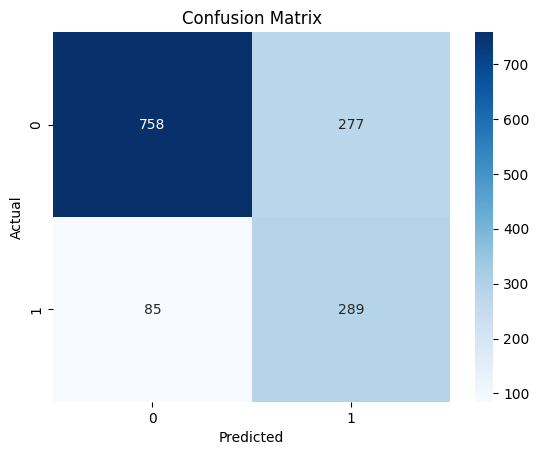

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
scoring = ['accuracy', 'precision', 'recall']
scores = cross_validate(stacking_model, X_train_selected, y_train, scoring=scoring, cv=5)

print("Accuracy scores:", scores['test_accuracy'])
print("Precision scores:", scores['test_precision'])
print("Recall scores:", scores['test_recall'])

print("Mean Accuracy:", scores['test_accuracy'].mean())
print("Mean Precision:", scores['test_precision'].mean())
print("Mean Recall:", scores['test_recall'].mean())

Accuracy scores: [0.77817214 0.77107365 0.75687666 0.73558119 0.72557726]
Precision scores: [0.55819477 0.54734411 0.5284738  0.50107991 0.48913043]
Recall scores: [0.78595318 0.79264214 0.77591973 0.77591973 0.75250836]
Mean Accuracy: 0.7534561805261142
Mean Precision: 0.5248446075382089
Mean Recall: 0.7765886287625419


## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

Agar lebih cepat disini kita akan gunakan RandomizeSearchCV dibandingkan GridSearchCV. Algoritma yang akan kita uji coba untuk melakukan Hyperparameter Tuning adalah Decision Tree dan Random Forest.

Pertama-tama kita akan coba lakukan Hyperparameter tuning untuk **Decision Tree**. Parameter yang akan kita atur:
- **max_depth**: Kedalaman maksimum decision tree. Semakin dalam, semakin kompleks modelnya dan berpotensi overfitting. None berarti tidak ada batasan kedalaman.

- **min_samples_split**: Jumlah minimum sampel yang dibutuhkan untuk membagi node internal. Nilai yang lebih tinggi mencegah overfitting dengan membuat tree yang lebih sederhana.

- **min_samples_leaf**: Jumlah minimum sampel yang dibutuhkan di setiap leaf node. Nilai yang lebih tinggi mencegah overfitting dengan membuat tree yang lebih sederhana.

- **criterion**: Fungsi untuk mengukur kualitas pembagian node. gini mengukur impurity, sedangkan entropy mengukur information gain.

- **class_weight**: Menyeimbangkan kelas jika data tidak seimbang. 'balanced' secara otomatis menyesuaikan bobot berdasarkan frekuensi kelas.

In [ ]:
# tuning dengan RandomSearchCV
param_grid= {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': range(2,6),
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced',None]

}

f1_scorer = make_scorer(f1_score, average='binary')  # Gunakan 'binary' untuk binary classification

random_search= RandomizedSearchCV(
    estimator= DecisionTreeClassifier(random_state=42),
    scoring=f1_scorer, #scoring f1-score
    n_iter=20,
    param_distributions=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_selected, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced', None],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 5, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': range(2, 6)},
                   scoring=make_scorer(f1_score, response_method='predict', average=binary),
                   verbose=1)

In [ ]:
random_search.best_params_

{'min_samples_split': 3,
 'min_samples_leaf': 1,
 'max_depth': 5,
 'criterion': 'entropy',
 'class_weight': 'balanced'}

In [ ]:
random_search.best_score_ #ini adalah score rata-rata dari cross validation

0.6096920039664061

In [ ]:
best_model= random_search.best_estimator_
best_model.fit(X_train_selected, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, min_samples_split=3, random_state=42)

In [ ]:
y_pred_train= best_model.predict(X_train_selected)
y_pred_test= best_model.predict(X_test_selected)

In [ ]:
print('Classification Report Train:')
print(classification_report(y_train, y_pred_train))

Classification Report Train:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      4139
           1       0.51      0.80      0.62      1495

    accuracy                           0.74      5634
   macro avg       0.71      0.76      0.71      5634
weighted avg       0.80      0.74      0.76      5634



In [ ]:
print('Classification Report Test:')
print(classification_report(y_test, y_pred_test))

Classification Report Test:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1035
           1       0.49      0.76      0.60       374

    accuracy                           0.73      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.79      0.73      0.74      1409



In [ ]:
#recall
print('recall train',recall_score(y_train, y_pred_train))
print('recall test',recall_score(y_test, y_pred_test))

recall train 0.8046822742474916
recall test 0.7620320855614974


Sekarang kita akan coba dengan R**andom Forest**. Berikut adalah parameter yang bisa digunakan:
- **n_estimators**: Jumlah pohon (decision trees) dalam model Random Forest. Semakin banyak pohon, umumnya model semakin akurat, tetapi juga lebih kompleks dan membutuhkan waktu training lebih lama.

- **max_depth**: Kedalaman maksimum setiap pohon dalam Random Forest. Semakin dalam pohon, semakin kompleks model dan berpotensi overfitting. Nilai None berarti tidak ada batasan kedalaman.

- **min_samples_split**: Jumlah minimum sampel yang dibutuhkan untuk membagi node internal dalam pohon. Nilai yang lebih tinggi mencegah overfitting dengan membuat tree yang lebih sederhana.

- **min_samples_leaf**: Jumlah minimum sampel yang dibutuhkan di setiap leaf node dalam pohon. Nilai yang lebih tinggi mencegah overfitting dengan membuat tree yang lebih sederhana.

- **bootstrap**: Menentukan apakah akan menggunakan bootstrap sampling saat membuat pohon. True berarti menggunakan bootstrap sampling, False berarti menggunakan seluruh data.

- **class_weight**: Menyeimbangkan kelas jika data tidak seimbang. 'balanced' secara otomatis menyesuaikan bobot berdasarkan frekuensi kelas, None berarti tidak ada penyesuaian bobot.

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': range(2, 6),
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'class_weight': ['balanced', None]
}

f1_scorer = make_scorer(f1_score, average='binary')

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    scoring=f1_scorer,
    n_iter=20,  # Number of parameter settings that are sampled
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42 #for reproducibility
)

random_search_rf.fit(X_train_selected, y_train)

print(random_search_rf.best_params_)
print(random_search_rf.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
0.628592982533352


In [ ]:
best_rf_model = random_search_rf.best_estimator_
y_pred_train_rf = best_rf_model.predict(X_train_selected)
y_pred_test_rf = best_rf_model.predict(X_test_selected)

print('Classification Report Train (Random Forest):')
print(classification_report(y_train, y_pred_train_rf))
print('Classification Report Test (Random Forest):')
print(classification_report(y_test, y_pred_test_rf))

print('Recall train (Random Forest):', recall_score(y_train, y_pred_train_rf))
print('Recall test (Random Forest):', recall_score(y_test, y_pred_test_rf))

Classification Report Train (Random Forest):
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      4139
           1       0.63      0.88      0.73      1495

    accuracy                           0.83      5634
   macro avg       0.79      0.85      0.81      5634
weighted avg       0.86      0.83      0.84      5634

Classification Report Test (Random Forest):
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Recall train (Random Forest): 0.8762541806020067
Recall test (Random Forest): 0.7192513368983957


Catatan:
- Jangan gunakan accuracy ketika datanya tidak seimbang (imbalance)
- Anda dapat menggunakan class_weight untuk menangani imbalance data, selain itu bisa juga atur threshold atau melakukan oversampling atau undersampling.
- Gunakan recall jika kita ingin meminimalkan FN
- Gunakan precission jika kita ingin meminimalkan FP
- Kalau ingin mempertimbangkan recall dan precision gunakan F1-Score

## Latihan

Selanjutnya coba lakukanlah beberapa hal berikut:
- Buatlah Pipeline baru bersama instruktur anda. Gabungkan pipeline preprocessing dan model ke dalam 1 pipeline.
- Lakukanlah model inference (prediksi terhadap data baru, misalkan dengan buat dummy data).
- Buatlah kesimpulan berdasarkan analisa EDA dan Model yang telah anda buat.

